## Problem Definition

### What variable are we predicting?
- We are predicting 'SalePrice' which tells at which price house was sold.

### Why is this a regression problem?
- Because sale values is a number an continues target and not a class.

### What evaluation metric is appropriate?
- RMSE is appropriate because it penalizes large prediction errors more strongly and produces error values in the same unit as the target variable (dollars), making it interpretable and appropriate for evaluating pricing models.

## Data Loading

In [166]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/train.csv", index_col=0)

df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


## Data Inspection

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [168]:
numerical_features = df.select_dtypes(include=[np.number]).columns[1:]
len(numerical_features)

36

In [169]:
categorical_features = [x for x in df.columns if x not in numerical_features]
len(categorical_features)

44

### How many features exist?
- Their are 80 Features in dataset for use to train model on.

### Which are numerical?
- 35 of them are numeric feature anf one is target.

### Which are categorical?
- 44 of them are categorical.

### Are missing values present?
- Yes their are missing values in dataset.


## Data Cleaning

In [170]:
df.shape

(1460, 80)

In [171]:
print(df.isnull().sum().sort_values(ascending=False).to_string())

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageQual         81
GarageType         81
GarageFinish       81
GarageCond         81
GarageYrBlt        81
BsmtExposure       38
BsmtFinType2       38
BsmtQual           37
BsmtFinType1       37
BsmtCond           37
MasVnrArea          8
Electrical          1
BldgType            0
Neighborhood        0
LandSlope           0
Condition2          0
Condition1          0
LandContour         0
LotShape            0
Street              0
LotArea             0
MSSubClass          0
MSZoning            0
LotConfig           0
Utilities           0
HouseStyle          0
Foundation          0
ExterQual           0
ExterCond           0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
BsmtFinSF1          0
Exterior2nd         0
Exterior1st         0
RoofMatl            0
RoofStyle           0
YearRemodAdd        0
OverallQua

In [172]:
df.drop("PoolQC", axis=1, inplace=True)
categorical_features.remove("PoolQC")

- We dropped `PoolQC` because it has many Null values and that null values represent NO POOL in the house but we also have `PoolArea` which can represent same thing.

- As for the other categorical features null does not means empty or missing data it is encoded as not available for feature representing it. So we need to keep all of them.

- As for the numerical features we will impute them to fill null values.

In [173]:
df.duplicated().value_counts()

False    1460
Name: count, dtype: int64

- As their are NO DUPLICATES we will not drop anything.

In [174]:
df[categorical_features] = df[categorical_features].fillna('None')

- Converted Null values to 'None' so that model does not tries to fill them in any method and learns that None means feature is not available in the house.

## Feature Engineering

In [175]:
df.insert(19, "Age", 2026 - df["YearBuilt"])

- We added how many years has it been since it's construction as feature `Age` because age can directly affect 



## Exploratory Data Analysis (EDA)

<Axes: xlabel='SalePrice'>

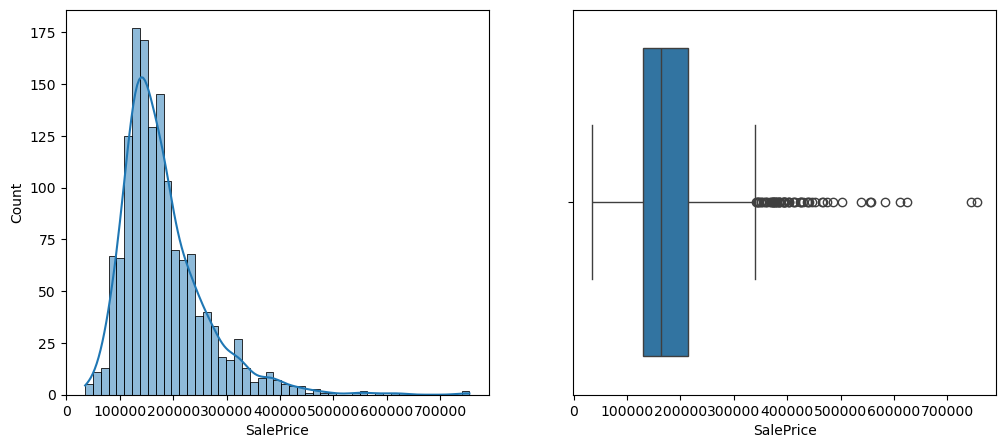

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt

figure, axes= plt.subplots(1,2, figsize=(12, 5))

sns.histplot(x = df["SalePrice"], data=df, kde=True, ax=axes[0])
sns.boxplot(x = df["SalePrice"], data=df, ax=axes[1])

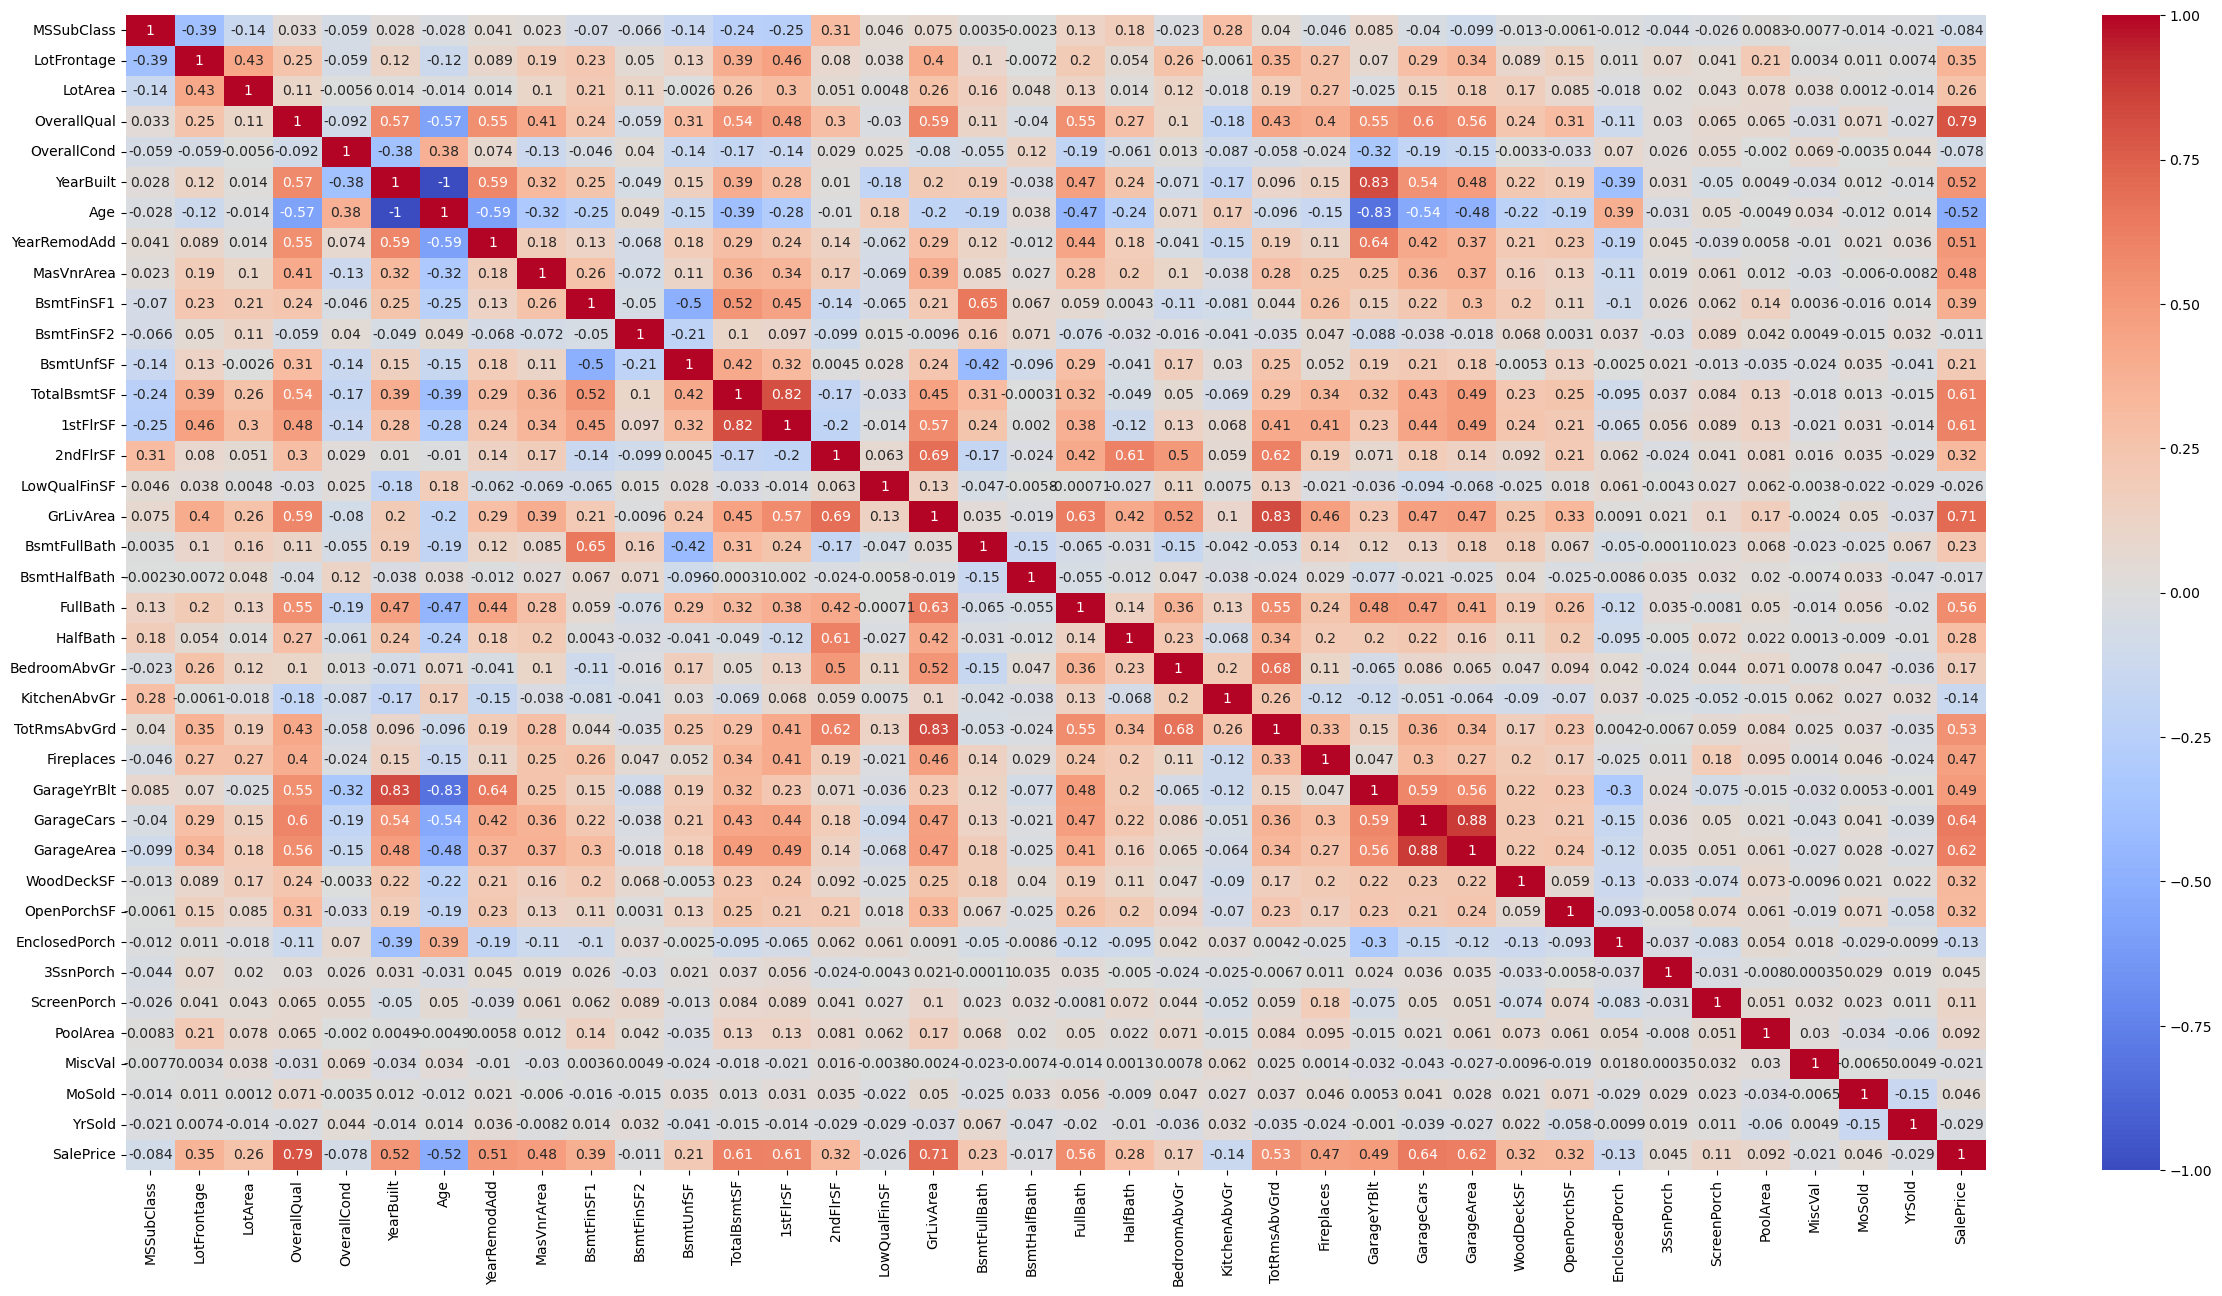

In [177]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(30,15))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)

plt.show()

- After observing co-relation matrix engineered feature `Age` makes much more sense.

## Baseline Model

In [178]:
numerical_features = list(df.select_dtypes(include=[np.number]).columns[1:-1])
categorical_features = [x for x in df.columns if x not in numerical_features][:-1]

In [179]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [180]:
from sklearn.model_selection import train_test_split

x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=42)

In [181]:
metric_evaluation = pd.DataFrame(columns=["RMSE", "RMSLE", "R^2"])

### Log Transform Target

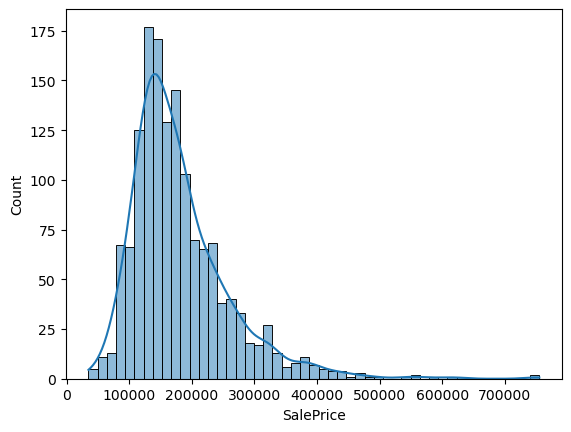

<Axes: xlabel='SalePrice', ylabel='Count'>

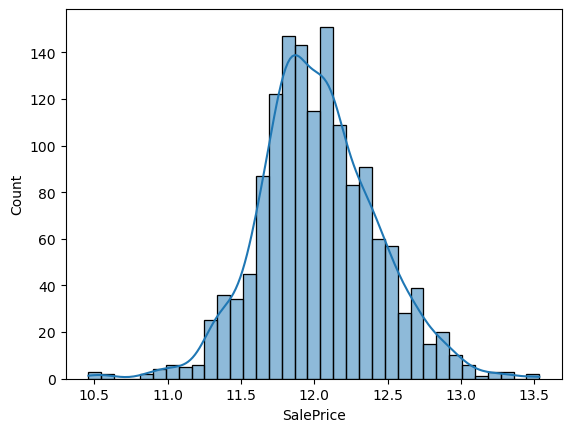

In [182]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

sns.histplot(y, kde=True)
plt.show()
sns.histplot(np.log1p(y), kde=True)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("linear", LinearRegression())
    ]
)

linear_model.fit(x_train, y_train)

y_pred = linear_model.predict(x_test)

metric_evaluation.loc["Linear Model"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

### Residual Analysis For Linear Model

Text(0.5, 1.0, 'Residual Plot')

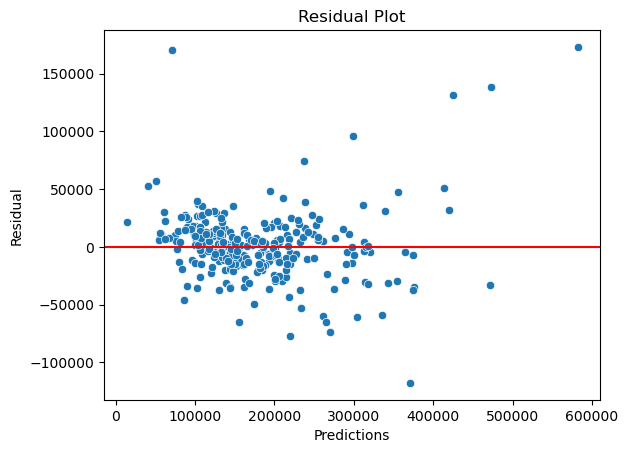

In [184]:
residual = y_test - y_pred

sns.scatterplot(x=y_pred, y=residual)
plt.axhline(0, color="red")
plt.xlabel("Predictions")
plt.ylabel("Residual")
plt.title("Residual Plot")

In [185]:
linear_model.fit(x_train, y_train_log)

y_pred_log = linear_model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log Linear Model"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

### Residual Analysis For Log Linear Model

Text(0.5, 1.0, 'Residual Plot')

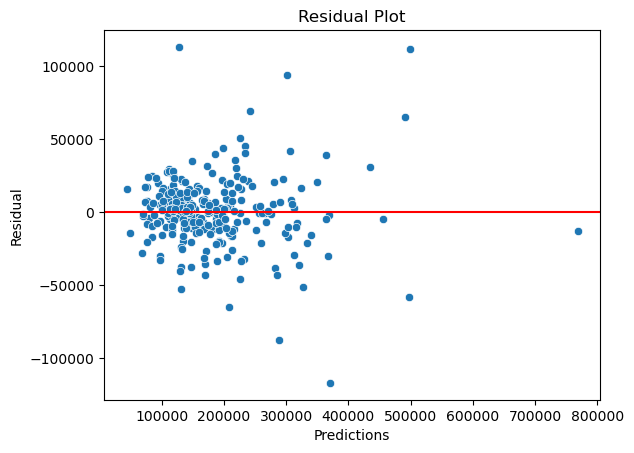

In [186]:
residual = y_test - y_pred

sns.scatterplot(x=y_pred, y=residual)
plt.axhline(0, color="red")
plt.xlabel("Predictions")
plt.ylabel("Residual")
plt.title("Residual Plot")

## Ridge Regression Models

In [187]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("ridge", Ridge(random_state=42))
    ]
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metric_evaluation.loc["Ridge"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

In [188]:
model.fit(x_train, y_train_log)

y_pred_log = model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log Ridge"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

## Lasso Regression Models

In [189]:
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("lasso", Lasso(random_state=42))
    ]
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metric_evaluation.loc["Lasso"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

/home/taksh/anaconda3/envs/ml-env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.556e+10, tolerance: 6.967e+08
  model = cd_fast.sparse_enet_coordinate_descent(


In [190]:
model.fit(x_train, y_train_log)

y_pred_log = model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log Lasso"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

## Tree-Based Models

In [191]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("randomforest", RandomForestRegressor(random_state=42))
    ]
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metric_evaluation.loc["Random Forest"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

In [192]:
model.fit(x_train, y_train_log)

y_pred_log = model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log Random Forest"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

## Boosting Model

In [193]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("gradiantboost", GradientBoostingRegressor(random_state=42))
    ]
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metric_evaluation.loc["Gradient Boost"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

In [194]:
model.fit(x_train, y_train_log)

y_pred_log = model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log Gradient Boost"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

## XGBoost Model

In [195]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("xgboost", XGBRegressor(random_state=42))
    ]
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

metric_evaluation.loc["XGBoost"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

In [196]:
model.fit(x_train, y_train_log)

y_pred_log = model.predict(x_test)

y_pred = np.expm1(y_pred_log)

metric_evaluation.loc["Log XGBoost"] = [root_mean_squared_error(y_test, y_pred), root_mean_squared_log_error(y_test, y_pred), r2_score(y_test, y_pred)]

## Model Comparison

In [197]:
metric_evaluation.sort_values(by="RMSE")

,RMSE,RMSLE,R^2
Log Linear Model,23126.528986,0.131238,0.930272
Log Ridge,24064.378818,0.130922,0.924502
XGBoost,25795.066406,0.146438,0.913252
Gradient Boost,27619.193734,0.144046,0.900549
Log XGBoost,27751.548828,0.150323,0.899594
Lasso,28172.704578,0.166744,0.896523
Random Forest,28706.961161,0.153349,0.892561
Log Random Forest,29188.930469,0.145704,0.888923
Ridge,29559.905587,0.158979,0.886082
Linear Model,29676.766485,0.183869,0.885180


- By observing metric table of all the models it is concluded that Log Linear Model is best performing out of all. In this model we take log(1 + x) of `SalePrice` which make distribution more natural and less skewed. We can further confirm this by observing residual plot which indicates that this model has less residual overall and at expensive price range it performs better than other model.

## Final Model Interpretation

- As decided in model comparison section Log Linear Model is best performance.

In [ ]:
import shap

x_train_trans = linear_model.named_steps["preprocessor"].transform(x_train)
x_test_trans = linear_model.named_steps["preprocessor"].transform(x_test)

explainer = shap.LinearExplainer(linear_model.named_steps["linear"] , masker=x_train_trans)

shap_values = explainer.shap_values(x_test_trans)

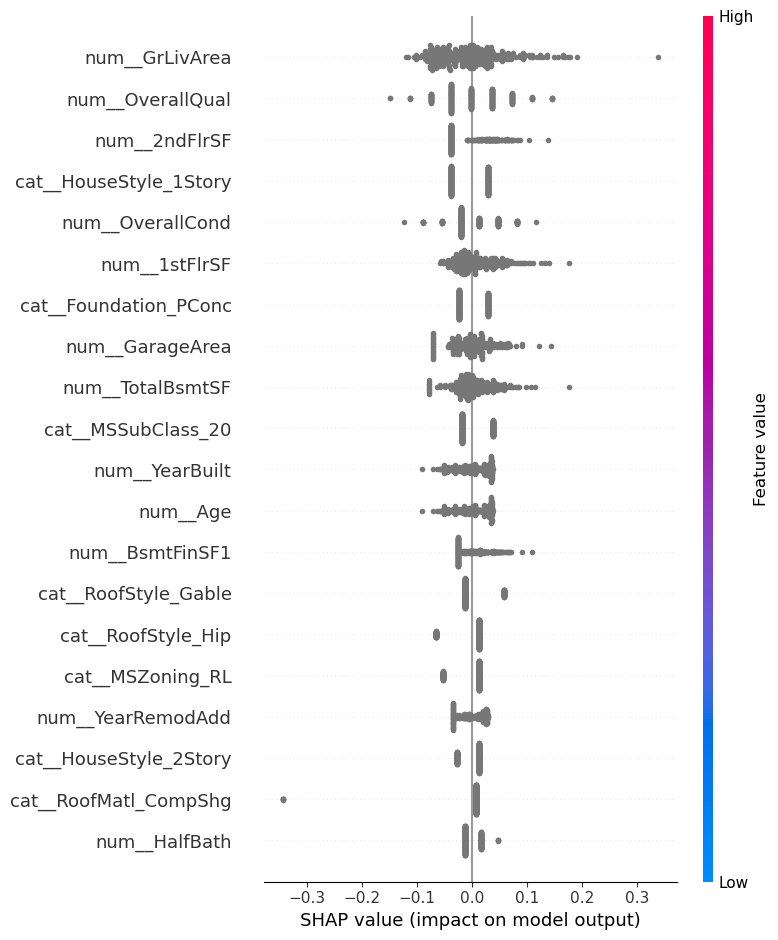

In [199]:
shap.summary_plot(shap_values, x_test_trans, feature_names)

## Final Model

In [204]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, root_mean_squared_log_error, r2_score

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("linear", LinearRegression())
    ]
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

linear_model.fit(x_train, y_train_log)

y_pred_log = linear_model.predict(x_test)

y_pred = np.expm1(y_pred_log)

print("RMSE : ", root_mean_squared_error(y_test, y_pred)) 
print("RMSLE : ", root_mean_squared_log_error(y_test, y_pred)) 
print("R^2 : ", r2_score(y_test, y_pred))

RMSE :  23126.52898600116
RMSLE :  0.13123811395978915
R^2 :  0.9302720212291352


### Final Metric of model is :
- RMSE :  23126.52898600116
- RMSLE :  0.13123811395978915
- R^2 :  0.9302720212291352